In [1]:
import pandas as pd
import japanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn import preprocessing

In [2]:
df = pd.read_excel('..\data\lifetime.xlsx',header=1)


In [3]:
df

,曜日,地域区分,男女 コード,男女,介護を受けているか否か及びその状況 コード,介護を受けているか否か及びその状況,年齢 コード,年齢,04_通勤・通学,11_移動(通勤・通学を除く),19_受診・療養
0,1_週全体,北海道,0,0_総数,0,0_総数,0,0_総数,24,19,7
1,1_週全体,北海道,0,0_総数,0,0_総数,1,1_30歳未満,38,22,5
2,1_週全体,北海道,0,0_総数,0,0_総数,2,2_30～39歳,29,15,5
3,1_週全体,北海道,0,0_総数,0,0_総数,3,3_40～49歳,31,19,4
4,1_週全体,北海道,0,0_総数,0,0_総数,4,4_50～59歳,30,20,4
...,...,...,...,...,...,...,...,...,...,...,...
3943,4_日曜日,沖縄県,2,2_女,0,0_総数,2,2_30～39歳,5,35,3
3944,4_日曜日,沖縄県,2,2_女,0,0_総数,3,3_40～49歳,10,50,2
3945,4_日曜日,沖縄県,2,2_女,0,0_総数,4,4_50～59歳,13,30,3
3946,4_日曜日,沖縄県,2,2_女,0,0_総数,5,5_60～69歳,7,21,2


In [4]:
df_all = df[(df['曜日']=='1_週全体')&(df['男女']=='0_総数')&(df['介護を受けているか否か及びその状況']=='0_総数')&(df['年齢']=='0_総数')]

In [5]:
df_all

,曜日,地域区分,男女 コード,男女,介護を受けているか否か及びその状況 コード,介護を受けているか否か及びその状況,年齢 コード,年齢,04_通勤・通学,11_移動(通勤・通学を除く),19_受診・療養
0,1_週全体,北海道,0,0_総数,0,0_総数,0,0_総数,24,19,7
21,1_週全体,青森県,0,0_総数,0,0_総数,0,0_総数,23,17,8
42,1_週全体,岩手県,0,0_総数,0,0_総数,0,0_総数,24,22,7
63,1_週全体,宮城県,0,0_総数,0,0_総数,0,0_総数,30,18,6
84,1_週全体,秋田県,0,0_総数,0,0_総数,0,0_総数,22,17,9
105,1_週全体,山形県,0,0_総数,0,0_総数,0,0_総数,21,17,9
126,1_週全体,福島県,0,0_総数,0,0_総数,0,0_総数,26,21,8
147,1_週全体,茨城県,0,0_総数,0,0_総数,0,0_総数,31,21,5
168,1_週全体,栃木県,0,0_総数,0,0_総数,0,0_総数,28,18,8
189,1_週全体,群馬県,0,0_総数,0,0_総数,0,0_総数,27,22,6


In [6]:
df_all.columns

Index(['曜日', '地域区分', '男女 コード', '男女', '介護を受けているか否か及びその状況 コード',
       '介護を受けているか否か及びその状況', '年齢 コード', '年齢', '04_通勤・通学', '11_移動(通勤・通学を除く)',
       '19_受診・療養'],
      dtype='object')

In [7]:
df_all['19_受診・療養'] = df_all['19_受診・療養'].astype(int)

C:\Users\junco\AppData\Local\Temp\ipykernel_20968\2895337357.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_all['19_受診・療養'] = df_all['19_受診・療養'].astype(int)


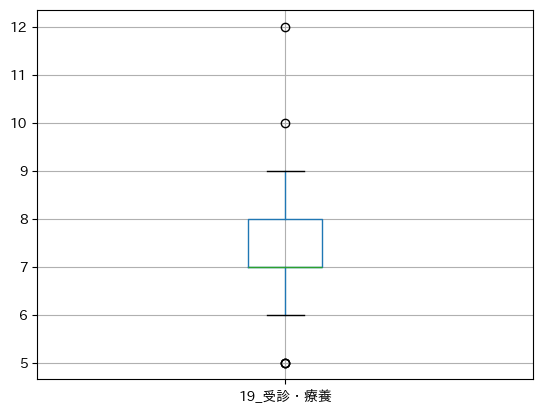

In [8]:
df_all.boxplot(column=['19_受診・療養'])
plt.show()

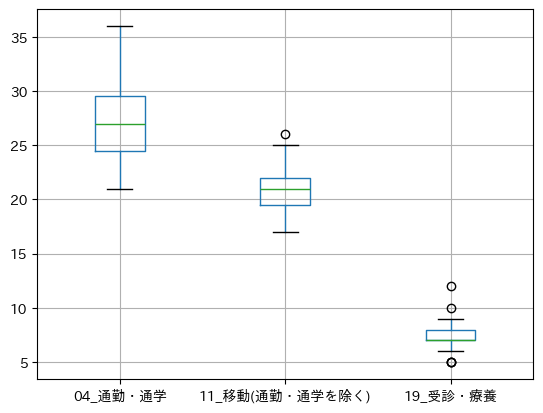

In [9]:
df_all.boxplot(column=[ '04_通勤・通学', '11_移動(通勤・通学を除く)','19_受診・療養'])
plt.show()

In [10]:
df_all.describe()

,男女 コード,介護を受けているか否か及びその状況 コード,年齢 コード,04_通勤・通学,11_移動(通勤・通学を除く),19_受診・療養
count,47.0,47.0,47.0,47.000000,47.000000,47.000000
mean,0.0,0.0,0.0,27.510638,20.765957,7.468085
std,0.0,0.0,0.0,4.164406,2.108088,1.316304
min,0.0,0.0,0.0,21.000000,17.000000,5.000000
25%,0.0,0.0,0.0,24.500000,19.500000,7.000000
50%,0.0,0.0,0.0,27.000000,21.000000,7.000000
75%,0.0,0.0,0.0,29.500000,22.000000,8.000000
max,0.0,0.0,0.0,36.000000,26.000000,12.000000


In [11]:
df_all[df_all['19_受診・療養']>7]

,曜日,地域区分,男女 コード,男女,介護を受けているか否か及びその状況 コード,介護を受けているか否か及びその状況,年齢 コード,年齢,04_通勤・通学,11_移動(通勤・通学を除く),19_受診・療養
21,1_週全体,青森県,0,0_総数,0,0_総数,0,0_総数,23,17,8
84,1_週全体,秋田県,0,0_総数,0,0_総数,0,0_総数,22,17,9
105,1_週全体,山形県,0,0_総数,0,0_総数,0,0_総数,21,17,9
126,1_週全体,福島県,0,0_総数,0,0_総数,0,0_総数,26,21,8
168,1_週全体,栃木県,0,0_総数,0,0_総数,0,0_総数,28,18,8
210,1_週全体,埼玉県,0,0_総数,0,0_総数,0,0_総数,36,23,8
315,1_週全体,富山県,0,0_総数,0,0_総数,0,0_総数,27,18,8
378,1_週全体,山梨県,0,0_総数,0,0_総数,0,0_総数,26,21,9
399,1_週全体,長野県,0,0_総数,0,0_総数,0,0_総数,27,20,10
483,1_週全体,三重県,0,0_総数,0,0_総数,0,0_総数,29,20,9


In [12]:
df_all[df_all['11_移動(通勤・通学を除く)']>25]

,曜日,地域区分,男女 コード,男女,介護を受けているか否か及びその状況 コード,介護を受けているか否か及びその状況,年齢 コード,年齢,04_通勤・通学,11_移動(通勤・通学を除く),19_受診・療養
252,1_週全体,東京都,0,0_総数,0,0_総数,0,0_総数,36,26,7


In [13]:
df['19_受診・療養'] = df['19_受診・療養'].replace('-', '0')

In [14]:
df['19_受診・療養'] = df['19_受診・療養'].astype(int)

In [15]:
df.describe()

,男女 コード,介護を受けているか否か及びその状況 コード,年齢 コード,04_通勤・通学,11_移動(通勤・通学を除く),19_受診・療養
count,3948.0000,3948.0,3948.000000,3948.000000,3948.000000,3948.000000
mean,1.0000,0.0,3.000000,22.860436,25.033181,5.874873
std,0.8166,0.0,2.000253,16.042524,9.418307,4.843227
min,0.0000,0.0,0.000000,1.000000,2.000000,0.000000
25%,0.0000,0.0,1.000000,9.750000,18.000000,2.000000
50%,1.0000,0.0,3.000000,19.000000,24.000000,5.000000
75%,2.0000,0.0,5.000000,34.000000,31.000000,8.000000
max,2.0000,0.0,6.000000,79.000000,64.000000,54.000000


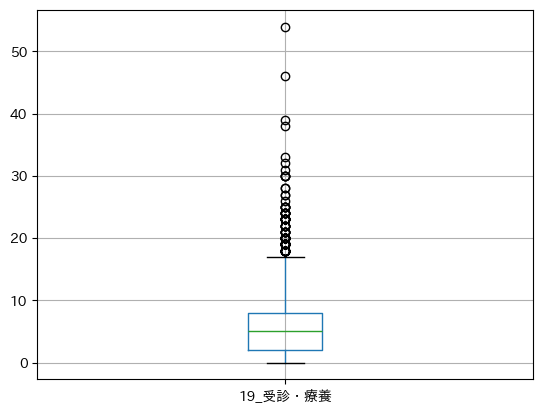

In [16]:
df.boxplot(column=['19_受診・療養'])
plt.show()

In [17]:
pd.set_option('display.max_rows', None)

In [18]:
df[df['19_受診・療養']>18]

,曜日,地域区分,男女 コード,男女,介護を受けているか否か及びその状況 コード,介護を受けているか否か及びその状況,年齢 コード,年齢,04_通勤・通学,11_移動(通勤・通学を除く),19_受診・療養
27,1_週全体,青森県,0,0_総数,0,0_総数,6,6_70歳以上,4,15,20
34,1_週全体,青森県,1,1_男,0,0_総数,6,6_70歳以上,6,15,25
97,1_週全体,秋田県,1,1_男,0,0_総数,6,6_70歳以上,6,18,24
188,1_週全体,栃木県,2,2_女,0,0_総数,6,6_70歳以上,3,11,19
230,1_週全体,埼玉県,2,2_女,0,0_総数,6,6_70歳以上,3,19,19
321,1_週全体,富山県,0,0_総数,0,0_総数,6,6_70歳以上,4,16,19
328,1_週全体,富山県,1,1_男,0,0_総数,6,6_70歳以上,7,18,23
398,1_週全体,山梨県,2,2_女,0,0_総数,6,6_70歳以上,3,14,19
405,1_週全体,長野県,0,0_総数,0,0_総数,6,6_70歳以上,4,16,20
408,1_週全体,長野県,1,1_男,0,0_総数,2,2_30～39歳,46,13,23


In [19]:
df['アクセス悪フラグ'] = 0  # まず全部0で初期化
df.loc[df['19_受診・療養'] > 18, 'アクセス悪フラグ'] = 1

In [20]:
df

,曜日,地域区分,男女 コード,男女,介護を受けているか否か及びその状況 コード,介護を受けているか否か及びその状況,年齢 コード,年齢,04_通勤・通学,11_移動(通勤・通学を除く),19_受診・療養,アクセス悪フラグ
0,1_週全体,北海道,0,0_総数,0,0_総数,0,0_総数,24,19,7,0
1,1_週全体,北海道,0,0_総数,0,0_総数,1,1_30歳未満,38,22,5,0
2,1_週全体,北海道,0,0_総数,0,0_総数,2,2_30～39歳,29,15,5,0
3,1_週全体,北海道,0,0_総数,0,0_総数,3,3_40～49歳,31,19,4,0
4,1_週全体,北海道,0,0_総数,0,0_総数,4,4_50～59歳,30,20,4,0
5,1_週全体,北海道,0,0_総数,0,0_総数,5,5_60～69歳,19,23,7,0
6,1_週全体,北海道,0,0_総数,0,0_総数,6,6_70歳以上,7,15,12,0
7,1_週全体,北海道,1,1_男,0,0_総数,0,0_総数,31,19,6,0
8,1_週全体,北海道,1,1_男,0,0_総数,1,1_30歳未満,42,20,5,0
9,1_週全体,北海道,1,1_男,0,0_総数,2,2_30～39歳,36,14,3,0


In [21]:
df_access = df.groupby('地域区分')['アクセス悪フラグ'].sum().reset_index()

In [22]:
df.sort_values('19_受診・療養',ascending=False).head(60)

,曜日,地域区分,男女 コード,男女,介護を受けているか否か及びその状況 コード,介護を受けているか否か及びその状況,年齢 コード,年齢,04_通勤・通学,11_移動(通勤・通学を除く),19_受診・療養,アクセス悪フラグ
1942,2_平日,鹿児島県,1,1_男,0,0_総数,3,3_40～49歳,54,12,54,1
2517,3_土曜日,京都府,2,2_女,0,0_総数,4,4_50～59歳,11,35,46,1
955,1_週全体,鹿児島県,1,1_男,0,0_総数,3,3_40～49歳,44,23,39,1
3369,4_日曜日,長野県,1,1_男,0,0_総数,2,2_30～39歳,13,30,38,1
1084,2_平日,秋田県,1,1_男,0,0_総数,6,6_70歳以上,7,18,33,1
1935,2_平日,鹿児島県,0,0_総数,0,0_総数,3,3_40～49歳,40,16,32,1
1021,2_平日,青森県,1,1_男,0,0_総数,6,6_70歳以上,6,16,31,1
3921,4_日曜日,鹿児島県,2,2_女,0,0_総数,1,1_30歳未満,9,36,30,1
1406,2_平日,長野県,2,2_女,0,0_総数,6,6_70歳以上,3,16,30,1
1315,2_平日,富山県,1,1_男,0,0_総数,6,6_70歳以上,8,20,30,1


In [23]:
df['平日アクセス悪フラグ'] = 0  # まず全部0で初期化
df.loc[(df['19_受診・療養'] > 18)&(df['曜日']=='2_平日'), '平日アクセス悪フラグ'] = 1

In [24]:
df[df['平日アクセス悪フラグ']==1].sort_values('19_受診・療養',ascending=False)

,曜日,地域区分,男女 コード,男女,介護を受けているか否か及びその状況 コード,介護を受けているか否か及びその状況,年齢 コード,年齢,04_通勤・通学,11_移動(通勤・通学を除く),19_受診・療養,アクセス悪フラグ,平日アクセス悪フラグ
1942,2_平日,鹿児島県,1,1_男,0,0_総数,3,3_40～49歳,54,12,54,1,1
1084,2_平日,秋田県,1,1_男,0,0_総数,6,6_70歳以上,7,18,33,1,1
1935,2_平日,鹿児島県,0,0_総数,0,0_総数,3,3_40～49歳,40,16,32,1,1
1021,2_平日,青森県,1,1_男,0,0_総数,6,6_70歳以上,6,16,31,1,1
1315,2_平日,富山県,1,1_男,0,0_総数,6,6_70歳以上,8,20,30,1,1
1406,2_平日,長野県,2,2_女,0,0_総数,6,6_70歳以上,3,16,30,1,1
1700,2_平日,広島県,2,2_女,0,0_総数,6,6_70歳以上,4,16,28,1,1
1798,2_平日,高知県,1,1_男,0,0_総数,6,6_70歳以上,9,21,28,1,1
1889,2_平日,熊本県,2,2_女,0,0_総数,6,6_70歳以上,6,13,27,1,1
1532,2_平日,京都府,2,2_女,0,0_総数,6,6_70歳以上,5,22,27,1,1


In [25]:
df_access_heijitu = df.groupby('地域区分')['平日アクセス悪フラグ'].sum().reset_index()

In [26]:
df_access = pd.merge(df_access, df_access_heijitu, on='地域区分', how='left')

In [27]:
df_dea = pd.read_csv('dataflame_dea.csv')

In [28]:
df_access = df_access.rename(columns={'地域区分': '都道府県'})

In [29]:
df_test = pd.merge(df_dea,df_access,how = 'left',on='都道府県')

In [30]:
df_test

,Unnamed: 0,都道府県,総人口,医師数,薬剤師数,一般病院数,一般診療所数,病院在院患者数,病院病床数,診療所在院患者数,...,病院病床数_人口10万人あたり,診療所患者数_人口10万人あたり,診療所病床数_人口10万人あたり,患者総数_人口10万人あたり,病床総数_人口10万人あたり,１日平均外来患者数合計_人口10万人あたり,効率値-in,効率値-out,アクセス悪フラグ,平日アクセス悪フラグ
0,0,北海道,5140000,13731,11802,471,3400,5646066,218636,23150,...,4253.618677,450.389105,40.700389,110296.031128,4294.319066,15450.291829,1.000000,1.000000,0,0
1,1,青森県,1204000,2773,2345,76,870,710921,27711,5408,...,2301.578073,449.169435,23.172757,59495.764120,2324.750831,12560.797342,1.000000,1.000000,5,3
2,2,岩手県,1181000,2700,2536,77,888,559454,23310,195,...,1973.751058,16.511431,27.180356,47387.722269,2000.931414,11191.701948,0.961478,1.115343,0,0
3,3,宮城県,2280000,5950,5502,109,1713,957801,37429,8968,...,1641.622807,393.333333,26.052632,42402.149123,1667.675439,10136.578947,1.000000,1.000000,0,0
4,4,秋田県,930000,2444,2066,50,822,539703,20820,6873,...,2238.709677,739.032258,30.000000,58771.612903,2268.709677,13419.247312,0.984062,1.024219,4,3
5,5,山形県,1041000,2608,2129,53,913,661688,24564,5768,...,2359.654179,554.082613,18.155620,64116.810759,2377.809798,12357.060519,1.000000,1.000000,1,1
6,6,福島県,1790000,3958,3792,101,1372,871459,34954,0,...,1952.737430,0.000000,13.575419,48684.860335,1966.312849,11825.474860,0.994886,1.008695,2,2
7,7,茨城県,2840000,5838,6704,152,1780,1468991,61407,9552,...,2162.218310,336.338028,16.408451,52061.373239,2178.626761,11540.598592,1.000000,1.000000,0,0
8,8,栃木県,1909000,4773,4350,89,1480,1121852,44258,4029,...,2318.386590,211.052907,15.086433,58977.527501,2333.473023,11886.066003,0.972334,1.050543,3,2
9,9,群馬県,1913000,4735,4130,115,1587,1185730,46166,2928,...,2413.277574,153.058024,3.763722,62135.807632,2417.041296,11446.628332,0.916465,1.203897,0,0


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [32]:
df_scaled = scaler.fit_transform(df_test[['一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり', '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり', '在院患者総数', '病床総数', '患者総数_人口10万人あたり', '病床総数_人口10万人あたり', '１日平均外来患者数合計_人口10万人あたり','平日アクセス悪フラグ','アクセス悪フラグ','効率値-in']])
df_scaled = pd.DataFrame(df_scaled, columns=['一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり', '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり', '在院患者総数', '病床総数', '患者総数_人口10万人あたり', '病床総数_人口10万人あたり', '１日平均外来患者数合計_人口10万人あたり','平日アクセス悪フラグ','アクセス悪フラグ','効率値-in'])

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
X = df_scaled[['一般病院数_人口10万人あたり',  '医師数_人口10万人あたり','薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり',   '病床総数_人口10万人あたり','アクセス悪フラグ']]

In [35]:
Y = df_scaled['１日平均外来患者数合計_人口10万人あたり']

In [36]:
model = LinearRegression()
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
df_coef = pd.DataFrame({'Variables':    X.columns,
                          'Coefficients': model.coef_.reshape(-1,)  
                        })
display( df_coef )

print( '切片:',  model.intercept_ )
print( '正解率:', model.score(X,Y) ) 

,Variables,Coefficients
0,一般病院数_人口10万人あたり,0.923792
1,医師数_人口10万人あたり,0.297910
2,薬剤師数_人口10万人あたり,-0.011874
3,一般診療所数_人口10万人あたり,-0.145638
4,病床総数_人口10万人あたり,-0.276479
5,アクセス悪フラグ,0.018995


切片: -6.578798609558294e-17
正解率: 0.7473727858336154


In [38]:
print(model.score(X,Y))

0.7473727858336154


In [39]:
Y = df_scaled[['効率値-in']]

In [40]:
model = LinearRegression()
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [41]:
df_coef = pd.DataFrame({'Variables':    X.columns,
                          'Coefficients': model.coef_.reshape(-1,)  
                        })
display( df_coef )

print( '切片:',  model.intercept_ )
print( '決定係数:', model.score(X,Y) ) 

,Variables,Coefficients
0,一般病院数_人口10万人あたり,0.278001
1,医師数_人口10万人あたり,0.079253
2,薬剤師数_人口10万人あたり,-0.052474
3,一般診療所数_人口10万人あたり,-0.628452
4,病床総数_人口10万人あたり,-0.559864
5,アクセス悪フラグ,0.094694


切片: [1.66362698e-15]
決定係数: 0.5556687669595272


In [42]:
X = df_scaled[['アクセス悪フラグ']]

In [43]:
model = LinearRegression()
model.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [44]:
df_coef = pd.DataFrame({'Variables':    X.columns,
                          'Coefficients': model.coef_.reshape(-1,)  
                        })
display( df_coef )

print( '切片:',  model.intercept_ )
print( '決定係数:', model.score(X,Y) ) 

,Variables,Coefficients
0,アクセス悪フラグ,0.047281


切片: [2.2518803e-15]
決定係数: 0.0022354762159504382


In [45]:
df_scaled['アクセス悪フラグ']

0    -0.863731
1     1.295597
2    -0.863731
3    -0.863731
4     0.863731
5    -0.431866
6     0.000000
7    -0.863731
8     0.431866
9    -0.863731
10    0.000000
11   -0.863731
12   -0.863731
13   -0.431866
14   -0.431866
15    1.295597
16   -0.863731
17   -0.863731
18    0.863731
19    3.023060
20    0.000000
21   -0.863731
22   -0.863731
23    0.000000
24    1.727463
25    1.727463
26   -0.431866
27   -0.863731
28   -0.863731
29   -0.863731
30   -0.863731
31    0.000000
32   -0.863731
33    1.295597
34   -0.863731
35    1.295597
36   -0.431866
37   -0.863731
38    0.431866
39    0.000000
40   -0.431866
41    0.000000
42    1.727463
43   -0.431866
44    0.863731
45    2.159328
46   -0.431866
Name: アクセス悪フラグ, dtype: float64

In [46]:
#多重共線性あり、特徴量をいじって70％くらいまで上げられるといいな。
#deaに投入した変数は説明変数として入れないほうがいいらしい。
# 都道府県の面積や人口構成（人口・人口密度）、経済水準（給与・家計消費）、交通手段（自家用車保有率）など取れるデータを使ったほうがよさそう。

In [47]:
df_c = pd.read_csv('..\data\ssdse_C_cleaned.csv')

In [48]:
df_c = df_c[['都道府県','食料（合計）']]

In [49]:
df_c

,都道府県,食料（合計）
0,全国,991375
1,北海道,927878
2,青森県,930707
3,岩手県,980028
4,宮城県,1003139
5,秋田県,952812
6,山形県,1028010
7,福島県,1008727
8,茨城県,925488
9,栃木県,1025725


In [50]:
df_d = pd.read_csv('..\data\ssdse_D_cleaned.csv')

In [51]:
df_d = df_d[df_d['男女の別']=='0_総数']

In [52]:
df_d = df_d[['都道府県','推定人口（10歳以上）']]

In [53]:
df_d

,都道府県,推定人口（10歳以上）
0,全国,112462
1,北海道,4614
2,青森県,1090
3,岩手県,1075
4,宮城県,2065
5,秋田県,849
6,山形県,944
7,福島県,1632
8,茨城県,2572
9,栃木県,1730


In [54]:
df_cd = pd.merge(df_c,df_d,on='都道府県')

In [55]:
df_cd

,都道府県,食料（合計）,推定人口（10歳以上）
0,全国,991375,112462
1,北海道,927878,4614
2,青森県,930707,1090
3,岩手県,980028,1075
4,宮城県,1003139,2065
5,秋田県,952812,849
6,山形県,1028010,944
7,福島県,1008727,1632
8,茨城県,925488,2572
9,栃木県,1025725,1730


In [56]:
df_car = pd.read_excel('..\data\car.xlsx',skiprows=2)

In [57]:
df_car = df_car.drop([0,8,17,22,28,35,41,46,54,56])

In [58]:
df_car = df_car.drop('局',axis = 1)

In [59]:
df_car = df_car.rename(columns={'車種':'都道府県'})

In [60]:
df_car

,都道府県,乗用車,貨物車,乗合車,特種（殊）車,二輪車,合計
1,北海道,2792718.0,679822.0,12561.0,162260.0,164433.0,3811794.0
2,青森,719659.0,212925.0,3361.0,32511.0,28975.0,997431.0
3,岩手,735588.0,219052.0,2974.0,26564.0,35743.0,1019921.0
4,宮城,1303985.0,288108.0,4399.0,35768.0,74361.0,1706621.0
5,秋田,577351.0,167072.0,1923.0,23906.0,23744.0,793996.0
6,山形,685219.0,182246.0,2186.0,23947.0,29748.0,923346.0
7,福島,1213103.0,320716.0,4344.0,36280.0,68802.0,1643245.0
9,茨城,2007299.0,487966.0,6279.0,51711.0,106483.0,2659738.0
10,栃木,1349646.0,291965.0,4016.0,32105.0,80864.0,1758596.0
11,群馬,1390484.0,320818.0,3304.0,33665.0,74691.0,1822962.0


In [61]:
df_car.at[55, '都道府県'] = '沖縄'

In [62]:
df_car['都道府県'] = df_car['都道府県'].apply(
    lambda x: x if x == '北海道' else (
        x + '都' if x in ['東京'] else
        x + '府' if x in ['大阪', '京都'] else
        x + '県'
    )
)


In [63]:
df_cdcar = pd.merge(df_cd,df_car,on='都道府県')

In [64]:
df_cdcar

,都道府県,食料（合計）,推定人口（10歳以上）,乗用車,貨物車,乗合車,特種（殊）車,二輪車,合計
0,北海道,927878,4614,2792718.0,679822.0,12561.0,162260.0,164433.0,3811794.0
1,青森県,930707,1090,719659.0,212925.0,3361.0,32511.0,28975.0,997431.0
2,岩手県,980028,1075,735588.0,219052.0,2974.0,26564.0,35743.0,1019921.0
3,宮城県,1003139,2065,1303985.0,288108.0,4399.0,35768.0,74361.0,1706621.0
4,秋田県,952812,849,577351.0,167072.0,1923.0,23906.0,23744.0,793996.0
5,山形県,1028010,944,685219.0,182246.0,2186.0,23947.0,29748.0,923346.0
6,福島県,1008727,1632,1213103.0,320716.0,4344.0,36280.0,68802.0,1643245.0
7,茨城県,925488,2572,2007299.0,487966.0,6279.0,51711.0,106483.0,2659738.0
8,栃木県,1025725,1730,1349646.0,291965.0,4016.0,32105.0,80864.0,1758596.0
9,群馬県,970070,1724,1390484.0,320818.0,3304.0,33665.0,74691.0,1822962.0


In [65]:
df_dea

,Unnamed: 0,都道府県,総人口,医師数,薬剤師数,一般病院数,一般診療所数,病院在院患者数,病院病床数,診療所在院患者数,...,一般診療所数_人口10万人あたり,病院患者数_人口10万人あたり,病院病床数_人口10万人あたり,診療所患者数_人口10万人あたり,診療所病床数_人口10万人あたり,患者総数_人口10万人あたり,病床総数_人口10万人あたり,１日平均外来患者数合計_人口10万人あたり,効率値-in,効率値-out
0,0,北海道,5140000,13731,11802,471,3400,5646066,218636,23150,...,66.147860,109845.642023,4253.618677,450.389105,40.700389,110296.031128,4294.319066,15450.291829,1.000000,1.000000
1,1,青森県,1204000,2773,2345,76,870,710921,27711,5408,...,72.259136,59046.594684,2301.578073,449.169435,23.172757,59495.764120,2324.750831,12560.797342,1.000000,1.000000
2,2,岩手県,1181000,2700,2536,77,888,559454,23310,195,...,75.190517,47371.210838,1973.751058,16.511431,27.180356,47387.722269,2000.931414,11191.701948,0.961478,1.115343
3,3,宮城県,2280000,5950,5502,109,1713,957801,37429,8968,...,75.131579,42008.815789,1641.622807,393.333333,26.052632,42402.149123,1667.675439,10136.578947,1.000000,1.000000
4,4,秋田県,930000,2444,2066,50,822,539703,20820,6873,...,88.387097,58032.580645,2238.709677,739.032258,30.000000,58771.612903,2268.709677,13419.247312,0.984062,1.024219
5,5,山形県,1041000,2608,2129,53,913,661688,24564,5768,...,87.704131,63562.728146,2359.654179,554.082613,18.155620,64116.810759,2377.809798,12357.060519,1.000000,1.000000
6,6,福島県,1790000,3958,3792,101,1372,871459,34954,0,...,76.648045,48684.860335,1952.737430,0.000000,13.575419,48684.860335,1966.312849,11825.474860,0.994886,1.008695
7,7,茨城県,2840000,5838,6704,152,1780,1468991,61407,9552,...,62.676056,51725.035211,2162.218310,336.338028,16.408451,52061.373239,2178.626761,11540.598592,1.000000,1.000000
8,8,栃木県,1909000,4773,4350,89,1480,1121852,44258,4029,...,77.527501,58766.474594,2318.386590,211.052907,15.086433,58977.527501,2333.473023,11886.066003,0.972334,1.050543
9,9,群馬県,1913000,4735,4130,115,1587,1185730,46166,2928,...,82.958704,61982.749608,2413.277574,153.058024,3.763722,62135.807632,2417.041296,11446.628332,0.916465,1.203897


In [66]:
df_access

,都道府県,アクセス悪フラグ,平日アクセス悪フラグ
0,三重県,2,2
1,京都府,6,3
2,佐賀県,1,1
3,兵庫県,0,0
4,北海道,0,0
5,千葉県,0,0
6,和歌山県,0,0
7,埼玉県,2,1
8,大分県,1,0
9,大阪府,1,1


In [67]:
df_deaacc = pd.merge(df_dea,df_access,on='都道府県')

In [68]:
df = pd.merge(df_cdcar,df_deaacc,on='都道府県')

In [69]:
print(list(df.columns))

['都道府県', '食料（合計）', '推定人口（10歳以上）', '乗用車', '貨物車', '乗合車', '特種（殊）車', '二輪車', '合計', 'Unnamed: 0', '総人口', '医師数', '薬剤師数', '一般病院数', '一般診療所数', '病院在院患者数', '病院病床数', '診療所在院患者数', '診療所病床数', '１日平均外来患者数合計', '年間外来患者数', '在院患者総数', '病床総数', '一般病院数_人口10万人あたり', '医師数_人口10万人あたり', '薬剤師数_人口10万人あたり', '一般診療所数_人口10万人あたり', '病院患者数_人口10万人あたり', '病院病床数_人口10万人あたり', '診療所患者数_人口10万人あたり', '診療所病床数_人口10万人あたり', '患者総数_人口10万人あたり', '病床総数_人口10万人あたり', '１日平均外来患者数合計_人口10万人あたり', '効率値-in', '効率値-out', 'アクセス悪フラグ', '平日アクセス悪フラグ']


In [70]:
X = df[['食料（合計）', '合計','総人口','平日アクセス悪フラグ']]
Y = df[ '効率値-in']

In [71]:
X_scaled = preprocessing.scale(X)

In [72]:
model=LinearRegression()

In [73]:
model.fit(X_scaled,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [74]:
df_coef = pd.DataFrame({'Variables':    X.columns,
                          'Coefficients': model.coef_.reshape(-1,)  
                        })
display( df_coef )

print( '切片:',  model.intercept_ )
print( '決定係数:', model.score(X_scaled,Y) ) 

,Variables,Coefficients
0,食料（合計）,0.035024
1,合計,0.037548
2,総人口,-0.059283
3,平日アクセス悪フラグ,-0.000567


切片: 0.9293947021276594
決定係数: 0.14090905364118045


In [75]:
#決定係数が低すぎ( ﾉД`)ｼｸｼｸ…

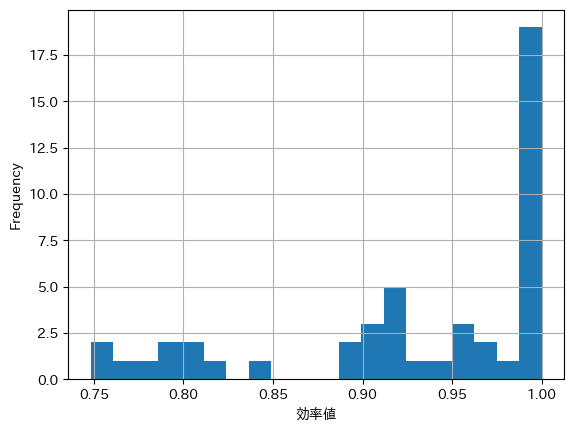

効率値=1の割合: 0.3829787234042553


In [77]:
df['効率値-in'].hist(bins=20)
plt.xlabel('効率値')
plt.ylabel('Frequency')
plt.show()

# 1に集中している割合
print("効率値=1の割合:", (df['効率値-in'] == 1).mean())


In [86]:
import numpy as np
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import norm

class TobitModel(GenericLikelihoodModel):
    def __init__(self, endog, exog, left=None, right=None, **kwds):
        self.left = left
        self.right = right
        super(TobitModel, self).__init__(endog, exog, **kwds)

    def loglike(self, params):
        beta = params[:-1]
        sigma = params[-1]
        y = self.endog
        X = self.exog
        XB = np.dot(X, beta)
        sig = abs(sigma)
        
        ll = np.zeros(len(y))
        # uncensored
        mask_unc = ( (self.left is None or y > self.left) & 
                     (self.right is None or y < self.right) )
        ll[mask_unc] = norm.logpdf((y[mask_unc] - XB[mask_unc]) / sig) - np.log(sig)
        # left-censored
        if self.left is not None:
            mask_left = (y <= self.left)
            ll[mask_left] = norm.logcdf((self.left - XB[mask_left]) / sig)
        # right-censored
        if self.right is not None:
            mask_right = (y >= self.right)
            ll[mask_right] = norm.logsf((self.right - XB[mask_right]) / sig)
        
        return ll.sum()

# データ準備
y = df['効率値-in']
X = df[['食料（合計）', '合計','平日アクセス悪フラグ']]
X = sm.add_constant(X)  # 定数項

# Tobit回帰実行（右側打ち切り = 1）
model = TobitModel(y, X, left=None, right=1)
start_params = np.append(np.zeros(X.shape[1]), 1)  # β=0, σ=1 で開始
result = model.fit(start_params=start_params, method='bfgs')
print(result.summary())


         Current function value: 0.326084
         Iterations: 9
         Function evaluations: 78
         Gradient evaluations: 66
                              TobitModel Results                              
Dep. Variable:                 効率値-in   Log-Likelihood:                -15.326
Model:                     TobitModel   AIC:                             40.65
Method:            Maximum Likelihood   BIC:                             49.90
Date:                Mon, 11 Aug 2025                                         
Time:                        22:20:57                                         
No. Observations:                  47                                         
Df Residuals:                      43                                         
Df Model:                           3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------

c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\scipy\optimize\_optimize.py:1330: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(f, x0, args, fprime, callback=callback, **opts)
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:595: HessianInversionWarning: Inverting hessian failed, no bse or cov_params available
  warnings.warn('Inverting hessian failed, no bse or cov_params '
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warnings.warn("df_model + k_constant + k_extra "
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site

In [87]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif_data)

      feature         VIF
0       const  291.344356
1      食料（合計）    1.479512
2          合計    1.580512
3  平日アクセス悪フラグ    1.086629


In [88]:
# Step1: 効率値=1のロジスティック回帰
df['is_one'] = (df['効率値-in'] == 1).astype(int)
logit_model = sm.Logit(df['is_one'], sm.add_constant(X.iloc[:, 1:]))  # 定数項除く
logit_res = logit_model.fit()
print(logit_res.summary())

# Step2: 効率値<1の部分だけOLS回帰
df_sub = df[df['効率値-in'] < 1]
ols_model = sm.OLS(df_sub['効率値-in'], sm.add_constant(df_sub.iloc[:, 1:]))
ols_res = ols_model.fit()
print(ols_res.summary())


Optimization terminated successfully.
         Current function value: 0.631082
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 is_one   No. Observations:                   47
Model:                          Logit   Df Residuals:                       43
Method:                           MLE   Df Model:                            3
Date:                Mon, 11 Aug 2025   Pseudo R-squ.:                 0.05172
Time:                        22:20:58   Log-Likelihood:                -29.661
converged:                       True   LL-Null:                       -31.279
Covariance Type:            nonrobust   LLR p-value:                    0.3567
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.3374      5.307     -0.629      0.529     -13.739       7.064
食料（合計）      2.041e-06   5.69e

c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\regression\linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\regression\linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\regression\linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:1527: RuntimeWarning: invalid value encountered in multiply
  cov_p = self.normalized_cov_params * scale


In [89]:
# 必要ライブラリ
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.base.model import GenericLikelihoodModel
from scipy.stats import norm
from statsmodels.stats.outliers_influence import variance_inflation_factor

# --- Tobit クラス（右側・左側の両方に対応） ---
class TobitModel(GenericLikelihoodModel):
    def __init__(self, endog, exog, left=None, right=None, **kwds):
        self.left = left
        self.right = right
        super(TobitModel, self).__init__(endog, exog, **kwds)

    def loglike(self, params):
        beta = params[:-1]
        sigma = params[-1]
        y = self.endog
        X = self.exog
        XB = np.dot(X, beta)
        sig = abs(sigma) + 1e-12  # numerically 安定化
        
        ll = np.zeros(len(y))
        # uncensored (strict inside bounds)
        mask_unc = ((self.left is None or y > self.left) & (self.right is None or y < self.right))
        if mask_unc.any():
            ll[mask_unc] = norm.logpdf((y[mask_unc] - XB[mask_unc]) / sig) - np.log(sig)
        # left-censored
        if self.left is not None:
            mask_left = (y <= self.left)
            if mask_left.any():
                ll[mask_left] = norm.logcdf((self.left - XB[mask_left]) / sig)
        # right-censored
        if self.right is not None:
            mask_right = (y >= self.right)
            if mask_right.any():
                ll[mask_right] = norm.logsf((self.right - XB[mask_right]) / sig)
        return ll.sum()

# --- データ準備（例） ---
# y: 目的変数（効率値, 右側打ち切り=1）
y = df['効率値-in'].values

# X: 説明変数（ここは必要に応じて調整）
X = df[['食料（合計）', '合計', '平日アクセス悪フラグ']].copy()
# 数値スケールが大きい場合は標準化した方が安定することが多い
X = (X - X.mean()) / X.std()
X = sm.add_constant(X)   # 定数項

# --- 共線性チェック（任意） ---
vif_data = pd.DataFrame({
    "feature": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print("VIF:\n", vif_data)

# --- Tobit モデル適合 ---
model = TobitModel(y, X, left=None, right=1.0)

# 初期値を指定（β=0, σ=0.2 など）
start_params = np.append(np.zeros(X.shape[1]), 0.2)

# method は 'powell' や 'bfgs' を試す（powell が安定することが多い）
res = model.fit(start_params=start_params, method='powell', maxiter=1000, disp=True)
print(res.summary())

# --- 予測: 観測される y の条件付き期待値 E[y|x] を計算 ---
# 右側打ち切り c = 1
beta_hat = res.params[:-1]
sigma_hat = abs(res.params[-1])

XB = X.values.dot(beta_hat)   # μ = Xβ
c = 1.0
z = (c - XB) / sigma_hat
Phi = norm.cdf(z)
phi = norm.pdf(z)

# 右側打ち切りの式（導出により）:
# E[y|x] = Φ(z)*μ - σ*φ(z) + c*(1 - Φ(z))
E_y_given_x = Phi * XB - sigma_hat * phi + c * (1 - Phi)

df['tobit_pred'] = E_y_given_x

# モデル適合指標（観測値との誤差）
from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(df['効率値-in'], df['tobit_pred'])
print("MAE (observed vs Tobit-pred):", mae)

# --- 平均的限界効果（数値微分） ---
# 各説明変数について、平均での dE[y]/dx を数値差分で求める
X_base = X.values.copy()
delta_scale = X.values.std(axis=0)  # 各列の標準偏差
marginal_effects = {}
for j, col in enumerate(X.columns):
    if col == 'const':
        continue
    delta = delta_scale[j] * 0.01  # 例: 標準偏差の1%変化を用いる
    X_pert = X_base.copy()
    X_pert[:, j] += delta
    XB_pert = X_pert.dot(beta_hat)
    z_pert = (c - XB_pert) / sigma_hat
    Phi_p = norm.cdf(z_pert); phi_p = norm.pdf(z_pert)
    E_pert = Phi_p * XB_pert - sigma_hat * phi_p + c * (1 - Phi_p)
    # 平均的限界効果（per unit change）
    avg_effect = (E_pert.mean() - E_y_given_x.mean()) / delta
    marginal_effects[col] = avg_effect

print("平均的限界効果（per unit change）:")
for k,v in marginal_effects.items():
    print(k, ":", v)


VIF:
       feature       VIF
0       const  1.000000
1      食料（合計）  1.479512
2          合計  1.580512
3  平日アクセス悪フラグ  1.086629
Optimization terminated successfully.
         Current function value: -0.148344
         Iterations: 5
         Function evaluations: 290
                              TobitModel Results                              
Dep. Variable:                      y   Log-Likelihood:                 6.9722
Model:                     TobitModel   AIC:                            -3.944
Method:            Maximum Likelihood   BIC:                             5.306
Date:                Mon, 11 Aug 2025                                         
Time:                        22:23:35                                         
No. Observations:                  47                                         
Df Residuals:                      43                                         
Df Model:                           3                                         
                 coef   

c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warnings.warn("df_model + k_constant + k_extra "
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:2752: UserWarning: df_resid differs from nobs - k_params
  warnings.warn("df_resid differs from nobs - k_params")


In [90]:
def tobit_fit_aic(y, X, left=None, right=1.0, start_sigma=0.2, verbose=True):
    """Tobitモデルを適合し、AICを返す"""
    model = TobitModel(y, X, left=left, right=right)
    start_params = np.append(np.zeros(X.shape[1]), start_sigma)
    res = model.fit(start_params=start_params, method='powell', maxiter=1000, disp=False)
    if verbose:
        print(f"AIC: {res.aic:.3f}  vars: {list(X.columns)}")
    return res

def backward_stepwise_tobit(y, X, left=None, right=1.0):
    current_X = X.copy()
    best_aic = np.inf
    best_res = None
    
    while True:
        results = []
        aics = []
        
        # 1変数ずつ削除して試す
        for col in current_X.columns.drop('const'):
            trial_X = current_X.drop(columns=[col])
            try:
                res = tobit_fit_aic(y, trial_X, left=left, right=right, verbose=False)
                results.append((res, trial_X))
                aics.append(res.aic)
            except Exception as e:
                # 最適化失敗などはスキップ
                continue
        
        if len(aics) == 0:
            break
        
        min_aic = min(aics)
        if min_aic < best_aic:
            best_aic = min_aic
            best_index = aics.index(min_aic)
            best_res, best_X = results[best_index]
            current_X = best_X
        else:
            # AIC改善しなかったら終了
            break
    
    return best_res, current_X

# 使用例
# 定数項は事前に追加しておくこと
X = df[['食料（合計）', '合計', '平日アクセス悪フラグ']].copy()
X = (X - X.mean()) / X.std()
X = sm.add_constant(X)

res_best, X_best = backward_stepwise_tobit(y, X, left=None, right=1.0)
print("最良モデルの説明変数:", list(X_best.columns))
print(res_best.summary())


最良モデルの説明変数: ['const', '食料（合計）']
                              TobitModel Results                              
Dep. Variable:                      y   Log-Likelihood:                 6.9342
Model:                     TobitModel   AIC:                            -7.868
Method:            Maximum Likelihood   BIC:                            -2.318
Date:                Mon, 11 Aug 2025                                         
Time:                        22:25:00                                         
No. Observations:                  47                                         
Df Residuals:                      45                                         
Df Model:                           1                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9609      0.019     50.820      0.000       0.924       0.998
食料（合計）         0.029

c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warnings.warn("df_model + k_constant + k_extra "
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:2752: UserWarning: df_resid differs from nobs - k_params
  warnings.warn("df_resid differs from nobs - k_params")
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warnings.warn("df_model + k_constant + k_extra "
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:2752: UserWarning: df_resid differs from nobs - k_params
  warnings.warn("df_resid differs from nobs - k_params")
c:\Users\junco\anaconda3\envs\healthcare-env\Lib\site-packages\statsmodels\base\model.py:2748: UserWarning: df_model + k_constant + k_extra differs from k_params
  warn